In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("diabetes.csv")

In [ ]:
# Number of rows and columns
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# First 5 rows
print("\nFirst 5 rows:")
print(df.head())

# Last 5 rows
print("\nLast 5 rows:")
print(df.tail())

# Dataset information
print("\nDataset Information:")
df.info()

Shape: (768, 9)

Columns:
Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

First 5 rows:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Last 5 rows:
     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
763          

In [ ]:
# Count duplicate rows

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
# Check missing values

print("Missing values after cleaning:")
print(df.isnull().sum())

# Check zero values

print("\nZero values:")
print((df == 0).sum())

# Display dataset information

print("\nDataset information:")
df.info()

# Display first five rows

print("\nCleaned dataset:")
print(df.head())

Missing values after cleaning:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Zero values:
Pregnancies                 111
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                     500
dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure       

In [ ]:
expected_columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

print("Missing Columns:")
print(set(expected_columns) - set(df.columns))

print("\nUnexpected Columns:")
print(set(df.columns) - set(expected_columns))

Missing Columns:
set()

Unexpected Columns:
set()


In [ ]:
# Count patients in each outcome category

print(df["Outcome"].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


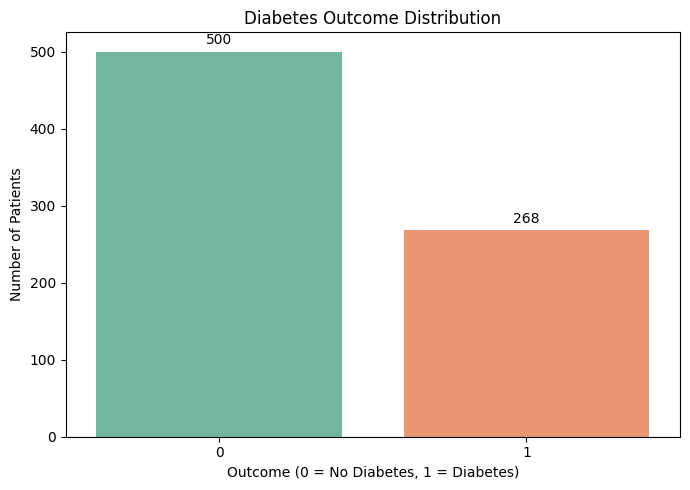

In [ ]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x="Outcome",
    hue="Outcome",
    palette="Set2",
    legend=False
)

# Display exact values above bars
for container in ax.containers:
    ax.bar_label(container, fmt="%d", padding=3)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.tight_layout()
plt.show()

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  AgeGroup  Outcome  
0                     0.627        50        1  
1                     0.351        31        0  
2                     0.672        32        1  
3                     0.167        21        0  
4                     2.288        33        1  


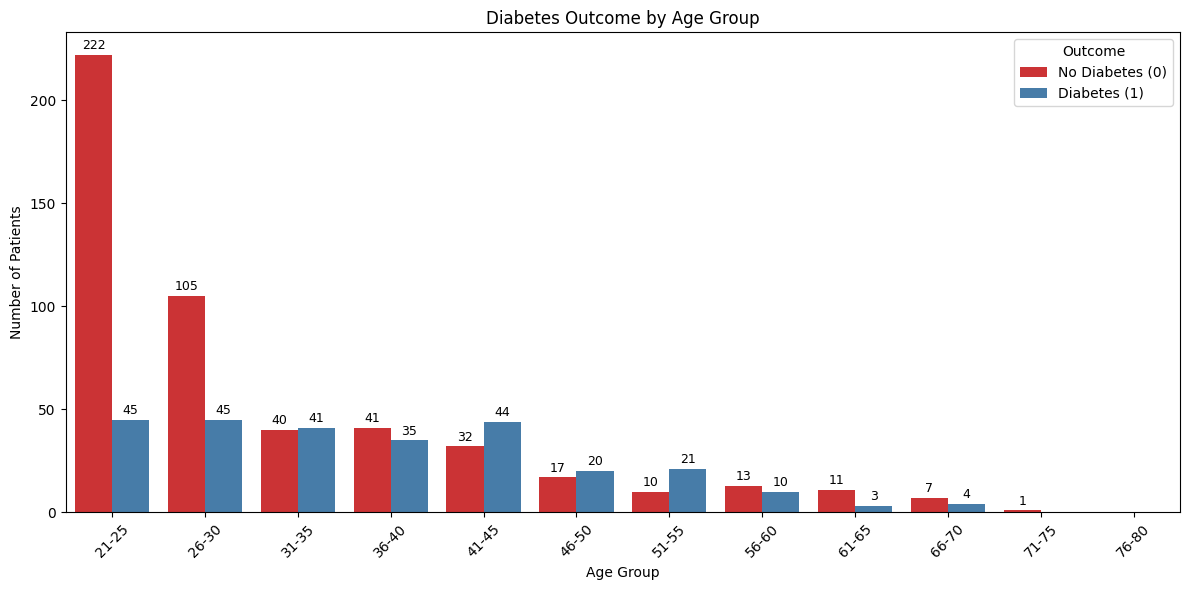

In [ ]:
df.rename(columns={"Age": "AgeGroup"}, inplace=True)

print(df.head())
# Create age groups
bins = [20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80]

labels = [
    "21-25", "26-30", "31-35", "36-40",
    "41-45", "46-50", "51-55", "56-60",
    "61-65", "66-70", "71-75", "76-80"
]

# Assign each patient to an age group
df["AgeGroup"] = pd.cut(
    df["AgeGroup"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

# Create the graph
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df,
    x="AgeGroup",
    hue="Outcome",
    palette="Set1"
)

# Display exact values above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=2,
        fontsize=9
    )

# Graph labels
plt.title("Diabetes Outcome by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Patients")

plt.xticks(rotation=45)

plt.legend(
    title="Outcome",
    labels=["No Diabetes (0)", "Diabetes (1)"]
)

plt.tight_layout()
plt.show()

In [ ]:
# Select input features (X)
X = df.drop(columns=["Outcome", "AgeGroup"], errors="ignore")

# Select target variable (y)
y = df["Outcome"]

# Display the features
print("Input Features (X):")
print(X.head())

# Display the target
print("\nTarget (y):")
print(y.head())

# Display shapes
print("\nX Shape:", X.shape)
print("y Shape:", y.shape)

Input Features (X):
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  
0                     0.627  
1                     0.351  
2                     0.672  
3                     0.167  
4                     2.288  

Target (y):
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

X Shape: (768, 7)
y Shape: (768,)


In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import make_pipeline, Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [ ]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Display the shapes
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (614, 8)
Testing Features: (154, 8)
Training Target: (614,)
Testing Target: (154,)


In [ ]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

numeric_features = X.select_dtypes(include=["number"]).columns
categorical_features = X.select_dtypes(include=["object", "category"]).columns

print("Numerical columns:", list(numeric_features))
print("Categorical columns:", list(categorical_features))

Numerical columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction']
Categorical columns: ['AgeGroup']


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Logistic Regression
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

log_model.fit(X_train, y_train)


# Decision Tree
dt_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

dt_model.fit(X_train, y_train)


# Random Forest
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

print("All three models trained successfully!")

All three models trained successfully!


In [ ]:
models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    results.append({
        "Algorithm": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0)
    })

results_df = pd.DataFrame(results)

print(results_df.round(4))

             Algorithm  Accuracy  Precision  Recall  F1 Score
0  Logistic Regression    0.7532     0.6667  0.5926    0.6275
1        Decision Tree    0.7208     0.6486  0.4444    0.5275
2        Random Forest    0.7662     0.6800  0.6296    0.6538


In [ ]:
# Predict using Random Forest
y_pred_rf = rf_model.predict(X_test)

# Display actual and predicted values
print("Actual Outcomes:")
print(y_test.head(10).values)

print("\nRandom Forest Predicted Outcomes:")
print(y_pred_rf[:10])

Actual Outcomes:
[0 0 0 1 0 0 1 1 0 0]

Random Forest Predicted Outcomes:
[1 0 0 0 0 0 1 1 0 1]


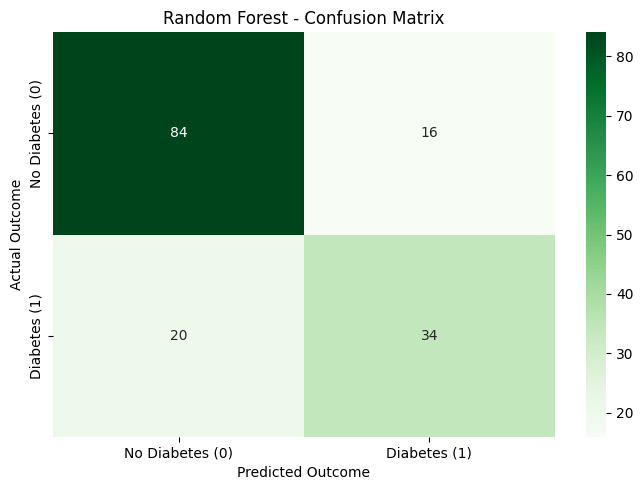

In [ ]:
from sklearn.metrics import confusion_matrix

# Confusion matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(7, 5))

ax = sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Diabetes (0)", "Diabetes (1)"],
    yticklabels=["No Diabetes (0)", "Diabetes (1)"]
)

plt.title("Random Forest - Confusion Matrix")

plt.xlabel("Predicted Outcome")
plt.ylabel("Actual Outcome")

plt.tight_layout()
plt.show()

In [ ]:
# Check new person

pregnancies = int(input("Enter pregnancies: "))
glucose = float(input("Enter glucose level: "))
blood_pressure = float(input("Enter blood pressure: "))
skin_thickness = float(input("Enter skin thickness: "))
insulin = float(input("Enter insulin level: "))
bmi = float(input("Enter BMI: "))
diabetes_pedigree = float(input("Enter diabetes pedigree function: "))
age = int(input("Enter age: "))

# Convert age into age group
if age <= 20:
    age_group = "0-20"
elif age <= 25:
    age_group = "21-25"
elif age <= 30:
    age_group = "26-30"
elif age <= 35:
    age_group = "31-35"
elif age <= 40:
    age_group = "36-40"
elif age <= 45:
    age_group = "41-45"
elif age <= 50:
    age_group = "46-50"
elif age <= 55:
    age_group = "51-55"
elif age <= 60:
    age_group = "56-60"
else:
    age_group = "60+"

# Create DataFrame
new_person = pd.DataFrame({
    "Pregnancies": [pregnancies],
    "Glucose": [glucose],
    "BloodPressure": [blood_pressure],
    "SkinThickness": [skin_thickness],
    "Insulin": [insulin],
    "BMI": [bmi],
    "DiabetesPedigreeFunction": [diabetes_pedigree],
    "AgeGroup": [age_group]
})

# Prediction
prediction = rf_model.predict(new_person)

print("\nRESULT")
print("------")

if prediction[0] == 1:
    print("Model prediction: Diabetes")
else:
    print("Model prediction: No Diabetes")

Enter pregnancies: 0
Enter glucose level: 65
Enter blood pressure: 188
Enter skin thickness: 43
Enter insulin level: 62
Enter BMI: 32
Enter diabetes pedigree function: 0.76
Enter age: 32

RESULT
------
Model prediction: No Diabetes


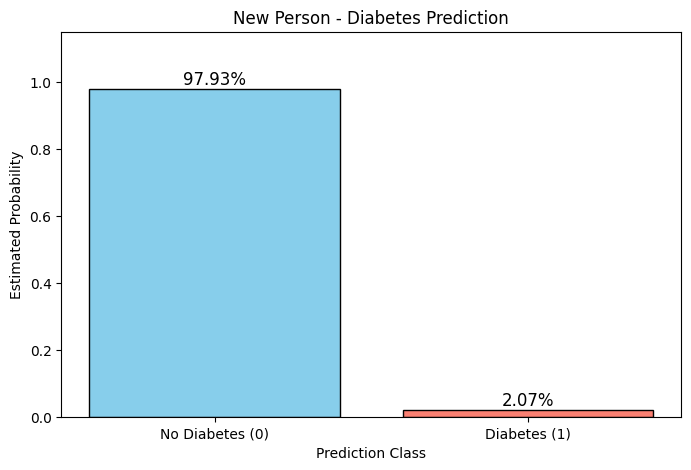

Model Prediction: No Diabetes


In [ ]:
# Get prediction
prediction = log_model.predict(new_person)

# Get probability for each class
probabilities = log_model.predict_proba(new_person)[0]

# Create graph
labels = ["No Diabetes (0)", "Diabetes (1)"]

plt.figure(figsize=(8, 5))

bars = plt.bar(
    labels,
    probabilities,
    color=["skyblue", "salmon"],
    edgecolor="black"
)

# Display exact probability values
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height * 100:.2f}%",
        ha="center",
        va="bottom",
        fontsize=12
    )

plt.title("New Person - Diabetes Prediction")
plt.xlabel("Prediction Class")
plt.ylabel("Estimated Probability")
plt.ylim(0, 1.15)

plt.show()

# Print final model output
if prediction[0] == 1:
    print("Model Prediction: Diabetes")
else:
    print("Model Prediction: No Diabetes")